# lab 10
## algoritmo dijktra

In [1]:
# Importar las librerias

#Libreria utilizada para graficar
import matplotlib.pyplot as plt 
#Libreria que me permite trabajaar con estructuras complejas, como Grafos
import networkx as nx 

In [2]:
# Creamos el grafo
grafo = nx.DiGraph()
grafo.add_weighted_edges_from([
        ("Centro","Este",25),
        ("Centro","Sur",15),
        ("Centro","Norte",10),
        ("Norte","Este",8),
        ("Norte","Sur",30),
        ("Norte","Oeste",15),
        ("Sur","Oeste",9),
        ("Oeste","Aeropuerto",18),
        ("Este","Aeropuerto",20)
])

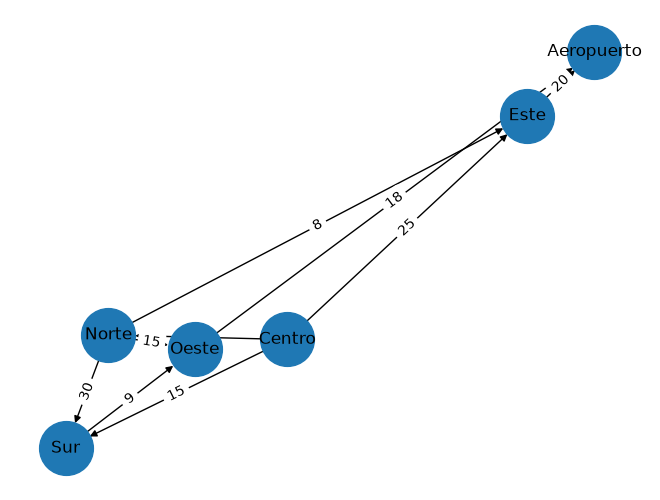

In [3]:
# Imprimimos el grafo

pos = nx.spring_layout(grafo, seed=10)

nx.draw(
    grafo,
    pos,
    with_labels = True,
    node_size = 1500,
    arrows = True
)

labels = nx.get_edge_attributes(grafo, "weight")

nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels = labels
)

plt.show()

In [4]:
# Mostramos las rutas
rutas = list(
    nx.all_simple_paths(
        grafo,
        source = "Centro",
        target = "Aeropuerto"
    )
)

In [5]:
# Imprimimos las rutas

for i, ruta in enumerate(rutas, start=1):
    print(f"Ruta {i}: {ruta}")

Ruta 1: ['Centro', 'Este', 'Aeropuerto']
Ruta 2: ['Centro', 'Sur', 'Oeste', 'Aeropuerto']
Ruta 3: ['Centro', 'Norte', 'Este', 'Aeropuerto']
Ruta 4: ['Centro', 'Norte', 'Sur', 'Oeste', 'Aeropuerto']
Ruta 5: ['Centro', 'Norte', 'Oeste', 'Aeropuerto']


In [6]:
# Grafos Dirigidos

# Calculamos el costo
def costo_ruta(grafo, ruta):
    costo = 0
    for i in range(len(ruta) - 1):
        costo += grafo[ruta[i]][ruta[i+1]]["weight"]
    return costo


In [7]:
# Imprimimos el costo
for i, ruta in enumerate(rutas, start=1):
    costo = costo_ruta(grafo, ruta)
    print(f"Ruta {i}: {ruta} -> {costo} unidades")

Ruta 1: ['Centro', 'Este', 'Aeropuerto'] -> 45 unidades
Ruta 2: ['Centro', 'Sur', 'Oeste', 'Aeropuerto'] -> 42 unidades
Ruta 3: ['Centro', 'Norte', 'Este', 'Aeropuerto'] -> 38 unidades
Ruta 4: ['Centro', 'Norte', 'Sur', 'Oeste', 'Aeropuerto'] -> 67 unidades
Ruta 5: ['Centro', 'Norte', 'Oeste', 'Aeropuerto'] -> 43 unidades


In [8]:
# Elegir la ruta más corta

costos = [costo_ruta(grafo, ruta) for ruta in rutas]

mejor_ruta = costos.index(min(costos))

In [9]:
# Imprimir la mejor ruta
print(f"La mejor ruta es: {mejor_ruta + 1}")
print(f"El camino corto es: {costos[mejor_ruta]}")

La mejor ruta es: 3
El camino corto es: 38


In [15]:
ruta_mas_corta=nx.dijkstra_path(grafo,source="Centro",target="Aeropuerto",
                                weight="weight")

In [16]:
tiempo_total=nx.dijkstra_path_length(grafo,source="Centro",target="Aeropuerto",
                                     weight="weight")

In [17]:
#imprimir
print (f"la ruta mas corta es: {ruta_mas_corta}")
print (f"el tiempo total es: {tiempo_total} minutos")

la ruta mas corta es: ['Centro', 'Norte', 'Este', 'Aeropuerto']
el tiempo total es: 38 minutos
